In [162]:
import torch



import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

from datasets.import_dataset import import_dataset
from trainer import Trainer
from utils.plotting import *

from utils.utils import clam_edges_from_feats


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# SBM 3X3



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:161:::  

Using dataset specific configuration and not global 




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:335:::  

 2025-07-07 20:22:12 starting optimization of bigclam on sbm3x3 on device cpu

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 2,
        "dim_attr": 100,
        "s_reg": 0.0,
        "l1_reg": 0.01,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-05,
        "n_iter": 10000,
        "early_stop": 0
    }
}


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../clamiter.py:365:::  
staring fit_feats for 10000 iterations


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../clamiter.py:393:::  

fit wrapper fit_feats, plotting state at iter 9999


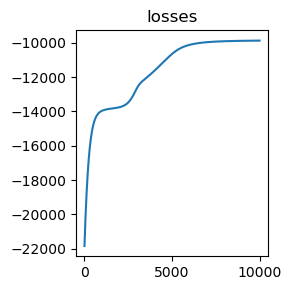

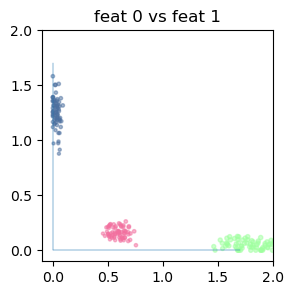

TEST accuracy.
Latest:
losses: -9868.0810546875 
Best:
losses: -9868.0810546875 at iteration 9999


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:438:::  



FINISHED train 
 last accuracies:
test
key='losses': -9868.0810546875




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:454:::  

train_model_on_params on bigclam sbm3x3 
took 11.176044702529907 seconds


In [3]:
data_sbm3x3 = import_dataset('sbm3x3')

config_triplets = [
    ['clamiter_init', 'dim_feat', 2],
    ['feat_opt', 'n_iter', 10000]
]

trainer_bigclam_sbm3x3 = Trainer(
    dataset=data_sbm3x3, 
    model_name='bigclam',
    config_triplets_to_change=config_triplets,
    device=device)

_ = trainer_bigclam_sbm3x3.train()

# Bipartite

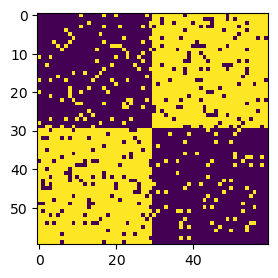

In [216]:
data_bipart = import_dataset('bipartite')
plot_sparse_adj(edge_index=data_bipart.edge_index, colorbar=False)



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../utils/plotting.py:27:::  
plotting 2 features


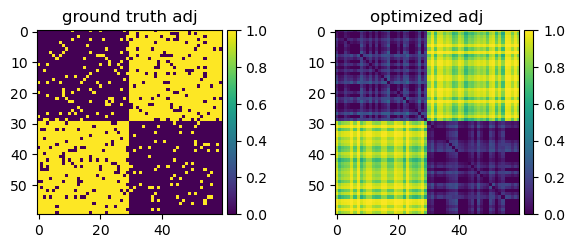

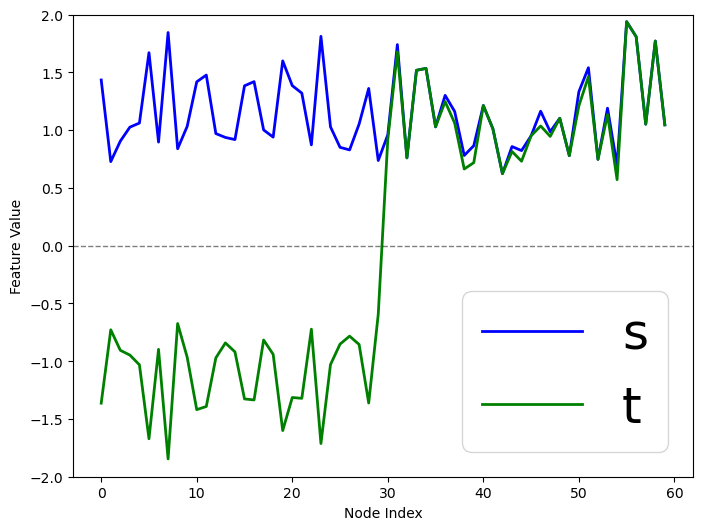

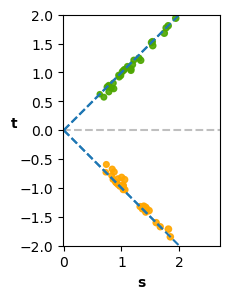

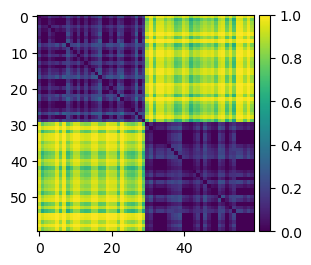

In [228]:
trainer_ieclam_bipart.plot_state(things_to_plot=['2dgraphs', 'feats', 'adj'], node_size_factor=1, draw_edges=False)


w = get_prob_graph(trainer_ieclam_bipart.data.x, lorenz=True)
plot_adj(w, colorbar=True)








/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:161:::  

Using dataset specific configuration and not global 




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:335:::  

 2025-07-11 00:47:02 starting optimization of ieclam on bipartite on device cpu

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 2,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 0.1,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 0.0001,
        "n_iter": 20000,
        "early_stop": 0
    }
}


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../clamiter.py:365:::  
staring fit_feats for 20000 iterations


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../clamiter.py:393:::  

fit wrapper fit_feats, plotting state at iter 19999


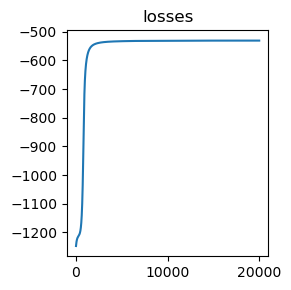

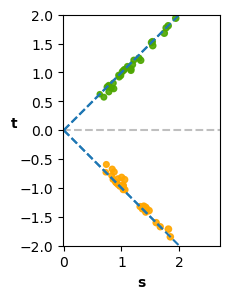

TEST accuracy.
Latest:
losses: -531.05517578125 
Best:
losses: -531.054931640625 at iteration 19994


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:438:::  



FINISHED train 
 last accuracies:
test
key='losses': -531.05517578125




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:454:::  

train_model_on_params on ieclam bipartite 
took 9.462270975112915 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../utils/plotting.py:27:::  
plotting 2 features


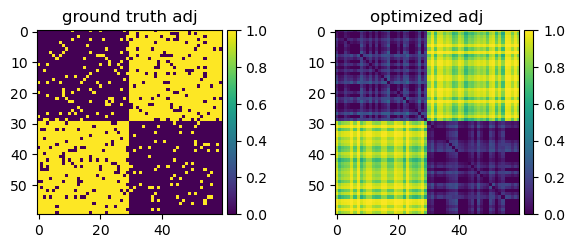

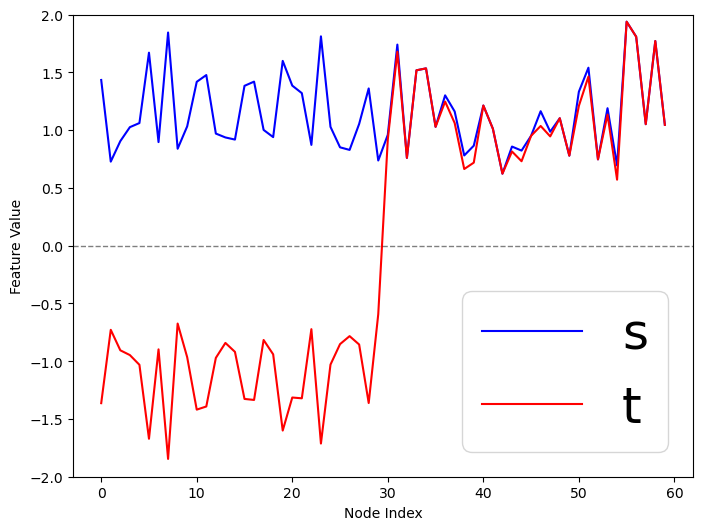

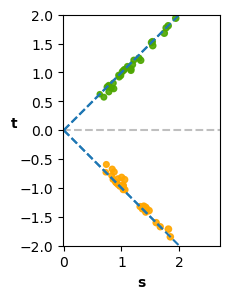

In [223]:

config_triplets=[
['feat_opt', 'lr', 0.0001],
['clamiter_init', 'dim_feat', 2],
['clamiter_init', 'l1_reg', 0.1],
['feat_opt', 'n_iter', 20000]

]

trainer_ieclam_bipart = Trainer(dataset=data_bipart, 
                                 model_name='ieclam',
                                 device='cpu',
                                 config_triplets_to_change=config_triplets,
                                 use_global_config_base=False
                                )

_ = trainer_ieclam_bipart.train(plot_every=-1)

trainer_ieclam_bipart.plot_state(things_to_plot=['adj', '2dgraphs', 'feats'], node_size_factor=1)


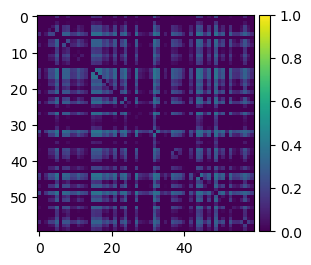

In [221]:
w = get_prob_graph(trainer_bigclam_bipart.data.x, lorenz=True)
plot_adj(w, colorbar=True)



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:161:::  

Using dataset specific configuration and not global 




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:335:::  

 2025-07-11 00:34:09 starting optimization of bigclam on bipartite on device cpu

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 2,
        "dim_attr": 100,
        "s_reg": 0.0,
        "l1_reg": 0.0,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-05,
        "n_iter": 20000,
        "early_stop": 0
    }
}


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../clamiter.py:365:::  
staring fit_feats for 20000 iterations


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../clamiter.py:393:::  

fit wrapper fit_feats, plotting state at iter 19999


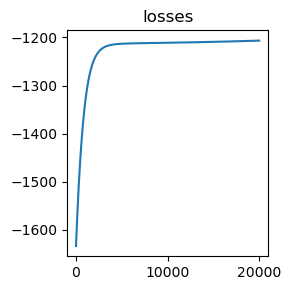

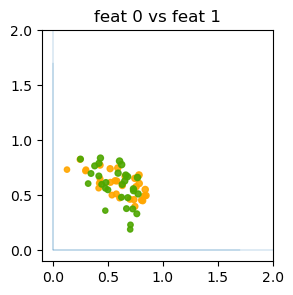

TEST accuracy.
Latest:
losses: -1206.7049560546875 
Best:
losses: -1206.7049560546875 at iteration 19999


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:438:::  



FINISHED train 
 last accuracies:
test
key='losses': -1206.7049560546875




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../trainer.py:454:::  

train_model_on_params on bigclam bipartite 
took 7.611814022064209 seconds


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/experiments/../utils/plotting.py:27:::  
plotting 2 features


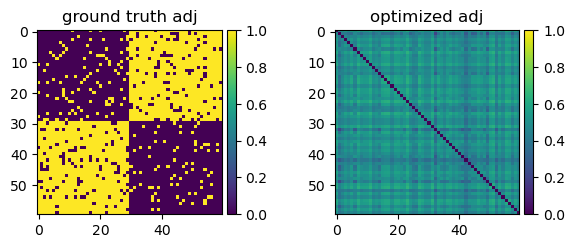

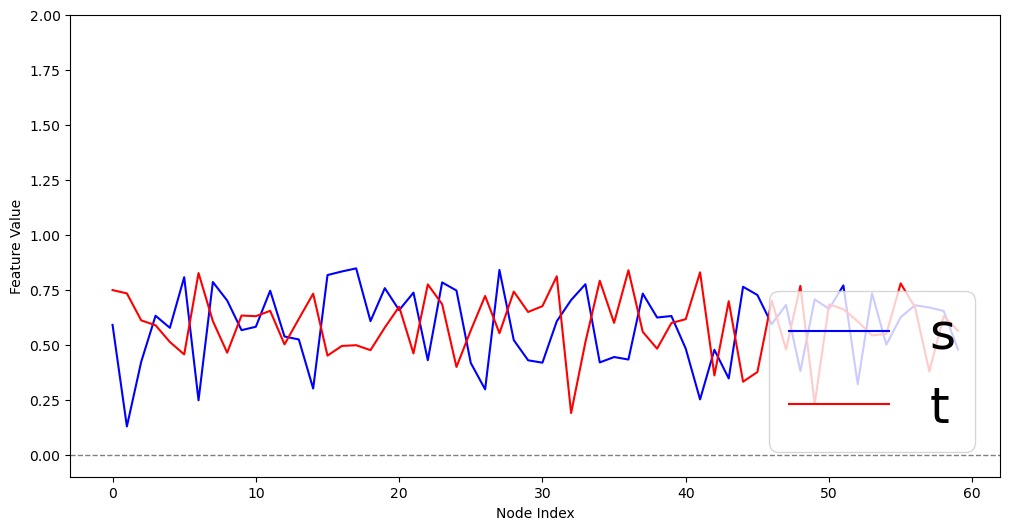

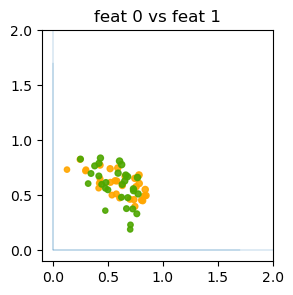

In [217]:

config_triplets=[
# ['feat_opt', 'lr', 0.001],
['clamiter_init', 'dim_feat', 2],
['clamiter_init', 'l1_reg', 0.0],
['feat_opt', 'n_iter', 20000]

]

trainer_bigclam_bipart = Trainer(dataset=data_bipart, 
                                 model_name='bigclam',
                                 device='cpu',
                                 config_triplets_to_change=config_triplets,
                                 use_global_config_base=False
                                )

_ = trainer_bigclam_bipart.train(plot_every=-1)

trainer_bigclam_bipart.plot_state(things_to_plot=['adj', '2dgraphs', 'feats'], node_size_factor=1)

In [ ]:
trainer_ieclam_bipart.plot_state(things_to_plot=['adj', '2dgraphs', 'feats'], draw_edges=True)

In [ ]:

config_triplets=[
# ['clamiter_init', 'dim_feat', 2],

]

trainer_ieclam_bipart = Trainer(dataset=data_bipart, 
                                 model_name='ieclam',
                                 device='cpu',
                                 config_triplets_to_change=config_triplets,
                                 global_configs_dict=False
                                )

_ = trainer_ieclam_bipart.train(plot_every=100000)
trainer_ieclam_bipart.plot_state(things_to_plot=['adj', '2dgraphs', 'feats'], draw_edges=True)